<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_02.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_02.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 02:** Implementation and Analysis of State Space Search Algorithms (BFS, DFS, and A*)

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this lab you will implement three classic **state space search** algorithms — Breadth-First Search (BFS), Depth-First Search (DFS), and A* Search — and compare how they navigate the same grid-based maze. You will visualize the explored cells and the final path for each algorithm and reason about why they behave differently.

### **Learning Objectives**

After completing this experiment, students will be able to:

- Represent a problem as a state space using a grid-based maze.
- Implement BFS, DFS, and A* search from first principles in Python.
- Reconstruct a solution path from parent pointers.
- Compare algorithms using path length, nodes expanded, and execution time.
- Explain why an admissible heuristic guarantees optimality in A*.
- Visualize and interpret search behaviour on a grid.

## **Theory**

### Introduction

State space search is one of the fundamental concepts in Artificial Intelligence. Many intelligent systems solve problems by exploring a collection of possible states to reach a desired goal. Breadth-first search explores level by level, depth-first search explores one branch deeply, and A* uses a heuristic to guide the search toward promising states.

Applications of state space search include:

- Robot navigation and path planning
- GPS and route optimization
- Autonomous vehicles
- Puzzle solving (8-Puzzle, Sudoku)
- Video game AI
- Chess and board game engines
- Automated planning systems

### Mathematical Background

A state space can be written as a directed graph $G = (V, E)$ where $V$ is the set of states and $E$ is the set of transitions. In A*, each node $n$ is evaluated using

$$f(n) = g(n) + h(n)$$

where $g(n)$ is the exact cost from the start node to $n$ and $h(n)$ is an admissible heuristic estimate from $n$ to the goal. If $h(n)$ never overestimates the true remaining cost, A* is complete and optimal for uniform or non-negative edge costs.

For grid-based pathfinding with horizontal and vertical movements, the Manhattan distance heuristic is defined as

$$h(n) = |x_1 - x_2| + |y_1 - y_2|$$

Because Manhattan distance never overestimates the actual shortest distance on a grid with unit-cost moves, it is an **admissible heuristic**, which guarantees that A* finds the shortest path when one exists.

### Important Concepts

- **BFS** uses a queue and guarantees the shortest path in an unweighted graph, exploring all nearby cells before moving farther away.
- **DFS** uses a stack (or recursion) and may reach the goal quickly but does **not** guarantee optimality.
- **A\*** maintains an open set ordered by the smallest $f(n)$ value and a closed set of expanded nodes, combining actual cost with heuristic estimate to search efficiently.

Each node represents a possible state, while each edge represents an action that transitions from one state to another. Search algorithms differ in the **order** they explore these nodes to reach the goal.

```
                Start
               /  |  \
              A   B   C
             / \      |
            D   E     F
               / \
             Goal G
```

### Advantages, Disadvantages, and Applications

**Advantages / Disadvantages**

- BFS is simple and complete, but can use a lot of memory.
- DFS is memory efficient, but can get stuck in deep or infinite branches and does not guarantee the shortest path.
- A* is efficient when a good heuristic is available, but its performance depends strongly on heuristic quality.

**Real-World Applications**

| Application | Algorithm |
|--------------|-----------|
| Google Maps Navigation | A* |
| Robot Navigation | A* |
| Warehouse Automation | A* |
| Chess Engines | Minimax + Search |
| Maze Solving | BFS / DFS |
| Puzzle Solving | BFS / A* |
| Autonomous Robots | A* |
| Game AI | DFS / A* |

```mermaid
flowchart TD
S[Start State] --> Q[BFS Queue or DFS Stack]
Q --> E[Expand Neighbors]
E --> H[A* Heuristic Evaluation]
H --> G[Goal Test]
G --> P[Reconstruct Path]
```

## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- NumPy
- Pandas
- Matplotlib
- (Optional) ipywidgets, for interactive dropdown comparisons

### Starter Check

Run the first code cell. If it prints `Setup complete. Ready to explore BFS, DFS, and A* search.`, your environment is ready.

## **Dataset Description**

This experiment does not use an external dataset. Instead, the "data" is a small **synthetic grid-world maze** represented as a NumPy array, which makes the notebook fully self-contained and easy to execute without downloads.

- **States:** grid cells represented by row and column coordinates.
- **Actions:** move up, down, left, or right.
- **Start state and goal state** are fixed in the map.
- **Why this is useful:** a small maze clearly shows how BFS, DFS, and A* behave differently while remaining easy to visualize.

## **Experimental Procedure**

Follow the steps below in order:

1. Run the import cell and confirm the setup message appears.
2. Represent the maze as a two-dimensional NumPy array and visualize it.
3. Implement valid-move checks, neighbor generation, and path reconstruction helpers.
4. Implement BFS, DFS, and A* search functions.
5. Run each algorithm from the same start and goal states.
6. Collect metrics such as path length, nodes expanded, and runtime.
7. Plot the maze and overlay the discovered paths for each algorithm.
8. Compare the algorithms in a summary table and bar chart.
9. Write short observations after reviewing the outputs.

### Student Checkpoint

Before moving to the discussion section, make sure you can answer:

- Which algorithm(s) found the shortest path in this maze?
- Which algorithm expanded the fewest nodes?
- Did BFS and A* choose the exact same route, or just the same length?


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Try changing the maze layout, the start/goal cells, or the neighbor ordering, and observe what changes.

In [1]:
import heapq
import time
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    widgets_available = True
except ImportError:
    widgets_available = False

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)
%matplotlib inline

print("Setup complete. Ready to explore BFS, DFS, and A* search.")


Setup complete. Ready to explore BFS, DFS, and A* search.


,item,value
0,Rows,8
1,Columns,8
2,Open cells,45
3,Blocked cells,19
4,Start,"(0, 0)"
5,Goal,"(7, 7)"


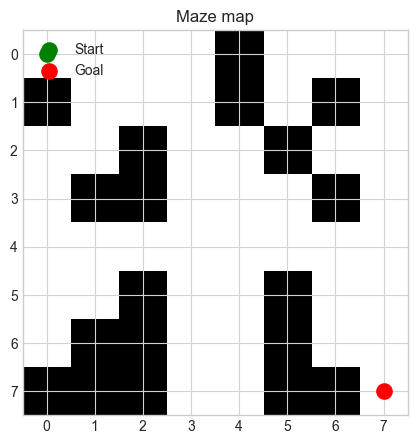

In [2]:
# Maze representation
# 0 = open cell, 1 = blocked cell

maze = np.array([
    [0, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 0, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0, 1, 0, 0],
    [1, 1, 1, 0, 0, 1, 1, 0],
])

start = (0, 0)
goal = (7, 7)

maze_info = pd.DataFrame({
    "item": ["Rows", "Columns", "Open cells", "Blocked cells", "Start", "Goal"],
    "value": [
        maze.shape[0],
        maze.shape[1],
        int((maze == 0).sum()),
        int((maze == 1).sum()),
        str(start),
        str(goal),
    ],
})
display(maze_info)

plt.figure(figsize=(5, 5))
plt.imshow(maze, cmap="gray_r")
plt.scatter(start[1], start[0], color="green", s=120, label="Start")
plt.scatter(goal[1], goal[0], color="red", s=120, label="Goal")
plt.xticks(range(maze.shape[1]))
plt.yticks(range(maze.shape[0]))
plt.grid(color="lightgray")
plt.title("Maze map")
plt.legend(loc="upper left")
plt.show()


In [3]:
# Helper functions used by all search algorithms
def in_bounds(position, grid):
    row, col = position
    return 0 <= row < grid.shape[0] and 0 <= col < grid.shape[1]


def is_open(position, grid):
    row, col = position
    return grid[row, col] == 0


def neighbors(position, grid):
    row, col = position
    candidates = [
        (row - 1, col),
        (row + 1, col),
        (row, col - 1),
        (row, col + 1),
    ]
    return [
        candidate
        for candidate in candidates
        if in_bounds(candidate, grid) and is_open(candidate, grid)
    ]


def reconstruct_path(parents, end_node):
    path = [end_node]
    while path[-1] in parents:
        path.append(parents[path[-1]])
    path.reverse()
    return path


def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


print("Helper functions are ready.")
print("Neighbors of start:", neighbors(start, maze))
print("Manhattan distance from start to goal:", manhattan(start, goal))


Helper functions are ready.
Neighbors of start: [(0, 1)]
Manhattan distance from start to goal: 14


#### Breadth-First Search (BFS)

BFS uses a queue. It explores all nearby cells first, then gradually moves farther away. In an unweighted maze, BFS guarantees a shortest path.

```
Start
  │
Initialize Queue
  │
Visit Node
  │
Goal Found?
 ├── Yes → Stop
 └── No
        │
 Add Unvisited Neighbors
        │
Repeat
```

In [4]:
def bfs(grid, start_node, goal_node):
    queue = deque([start_node])
    parents = {}
    visited = {start_node}
    expanded_order = []

    while queue:
        current = queue.popleft()
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in neighbors(current, grid):
            if neighbor not in visited:
                visited.add(neighbor)
                parents[neighbor] = current
                queue.append(neighbor)

    return None, expanded_order


print("BFS function created. It uses a queue and finds a shortest path.")


BFS function created. It uses a queue and finds a shortest path.


#### Depth-First Search (DFS)

DFS uses a stack. It follows one branch as far as possible before backtracking. DFS may find a valid path quickly, but it does not guarantee the shortest path.

```
Start
  │
Initialize Stack
  │
Visit Node
  │
Goal Found?
 ├── Yes → Stop
 └── No
        │
Push Neighbor
        │
Repeat
```

In [5]:
def dfs(grid, start_node, goal_node):
    stack = [start_node]
    parents = {}
    visited = {start_node}
    expanded_order = []

    while stack:
        current = stack.pop()
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in reversed(neighbors(current, grid)):
            if neighbor not in visited:
                visited.add(neighbor)
                parents[neighbor] = current
                stack.append(neighbor)

    return None, expanded_order


print("DFS function created. It uses a stack and may return a longer route.")


DFS function created. It uses a stack and may return a longer route.


#### A* Search

A* uses both actual cost and heuristic cost: $f(n) = g(n) + h(n)$. Here, $g(n)$ is the distance from the start and $h(n)$ is Manhattan distance to the goal.

```
Start
  │
Priority Queue
  │
Choose Lowest f(n)
  │
Goal Found?
 ├── Yes → Stop
 └── No
        │
Compute g(n)+h(n)
        │
Repeat
```

In [6]:
def a_star(grid, start_node, goal_node):
    open_heap = [(manhattan(start_node, goal_node), 0, start_node)]
    parents = {}
    g_score = {start_node: 0}
    closed = set()
    expanded_order = []

    while open_heap:
        _, current_cost, current = heapq.heappop(open_heap)

        if current in closed:
            continue

        closed.add(current)
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in neighbors(current, grid):
            new_cost = current_cost + 1

            if new_cost < g_score.get(neighbor, float("inf")):
                g_score[neighbor] = new_cost
                parents[neighbor] = current
                priority = new_cost + manhattan(neighbor, goal_node)
                heapq.heappush(open_heap, (priority, new_cost, neighbor))

    return None, expanded_order


print("A* function created. It uses Manhattan distance to guide the search.")


A* function created. It uses Manhattan distance to guide the search.


In [7]:
# Run all algorithms
algorithms = {
    "BFS": bfs,
    "DFS": dfs,
    "A*": a_star,
}


def run_algorithm(name, algorithm):
    start_time = time.perf_counter()
    path, expanded_order = algorithm(maze, start, goal)
    elapsed = time.perf_counter() - start_time

    return {
        "algorithm": name,
        "path": path,
        "expanded_order": expanded_order,
        "path_length": len(path) - 1 if path else None,
        "expanded_nodes": len(expanded_order),
        "time_ms": elapsed * 1000,
    }


results = [run_algorithm(name, algorithm) for name, algorithm in algorithms.items()]

for result in results:
    print(
        f"{result['algorithm']}: path length = {result['path_length']}, "
        f"expanded nodes = {result['expanded_nodes']}"
    )


BFS: path length = 14, expanded nodes = 39
DFS: path length = 18, expanded nodes = 26
A*: path length = 14, expanded nodes = 29


In [8]:
# Full path visualization
colors = {
    "BFS": "#457b9d",
    "DFS": "#e76f51",
    "A*": "#2a9d8f",
}


def plot_search_result(algorithm_name="A*"):
    result = next(item for item in results if item["algorithm"] == algorithm_name)
    path = result["path"]
    expanded_order = result["expanded_order"]

    plt.figure(figsize=(6, 6))
    plt.imshow(maze, cmap="gray_r")

    if expanded_order:
        expanded_rows = [position[0] for position in expanded_order]
        expanded_cols = [position[1] for position in expanded_order]
        plt.scatter(expanded_cols, expanded_rows, color="#f4a261", alpha=0.35, s=90, label="Expanded")

    if path:
        path_rows = [position[0] for position in path]
        path_cols = [position[1] for position in path]
        plt.plot(path_cols, path_rows, marker="o", color=colors[algorithm_name], linewidth=2.5, label="Path")

    plt.scatter(start[1], start[0], color="green", s=130, label="Start")
    plt.scatter(goal[1], goal[0], color="red", s=130, label="Goal")
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(color="lightgray")
    plt.title(f"{algorithm_name}: path and expanded cells")
    plt.legend(loc="upper left")
    plt.show()

    print("Path:", path)


if widgets_available:
    interact(plot_search_result, algorithm_name=list(algorithms.keys()))
else:
    for name in algorithms:
        plot_search_result(name)


interactive(children=(Dropdown(description='algorithm_name', index=2, options=('BFS', 'DFS', 'A*'), value='A*'…

,algorithm,path_length,expanded_nodes,time_ms
0,BFS,14,39,0.3189
1,DFS,18,26,0.2287
2,A*,14,29,0.3294


Shortest path found by: BFS
Fewest expanded nodes: DFS


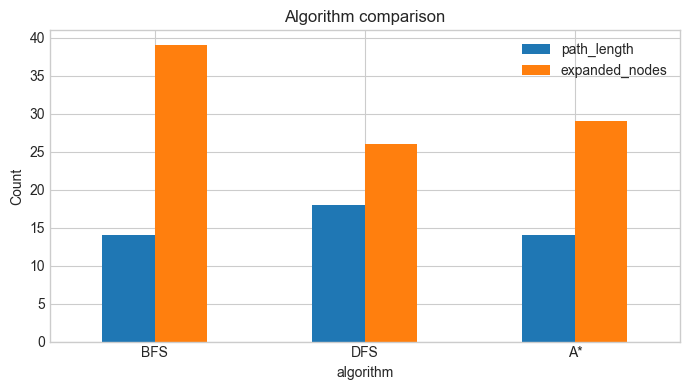

In [9]:
# Comparison in a separate cell
results_df = pd.DataFrame([
    {
        "algorithm": result["algorithm"],
        "path_length": result["path_length"],
        "expanded_nodes": result["expanded_nodes"],
        "time_ms": result["time_ms"],
    }
    for result in results
])

display(results_df.round(4))

best_path = results_df.loc[results_df["path_length"].idxmin(), "algorithm"]
best_expansion = results_df.loc[results_df["expanded_nodes"].idxmin(), "algorithm"]

print("Shortest path found by:", best_path)
print("Fewest expanded nodes:", best_expansion)

results_df.plot(
    x="algorithm",
    y=["path_length", "expanded_nodes"],
    kind="bar",
    figsize=(7, 4),
    rot=0,
    title="Algorithm comparison",
)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [10]:
# Animated navigation from start to goal
def animate_path(algorithm_name="A*", interval=600):
    result = next(item for item in results if item["algorithm"] == algorithm_name)
    path = result["path"]

    if not path:
        print("No path found.")
        return

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(maze, cmap="gray_r")

    path_rows = [position[0] for position in path]
    path_cols = [position[1] for position in path]
    ax.plot(path_cols, path_rows, color=colors[algorithm_name], linewidth=2, alpha=0.35)

    visited_line, = ax.plot([], [], marker="o", color=colors[algorithm_name], linewidth=3)
    current_dot = ax.scatter([], [], color="gold", edgecolor="black", s=180, label="Current")

    ax.scatter(start[1], start[0], color="green", s=130, label="Start")
    ax.scatter(goal[1], goal[0], color="red", s=130, label="Goal")
    ax.set_xticks(range(maze.shape[1]))
    ax.set_yticks(range(maze.shape[0]))
    ax.grid(color="lightgray")
    ax.legend(loc="upper left")

    def update(frame):
        visited_line.set_data(path_cols[: frame + 1], path_rows[: frame + 1])
        current_dot.set_offsets([[path_cols[frame], path_rows[frame]]])
        ax.set_title(f"{algorithm_name} navigation: step {frame} of {len(path) - 1}")
        return visited_line, current_dot

    animation = FuncAnimation(
        fig,
        update,
        frames=len(path),
        interval=interval,
        repeat=False,
        blit=False,
    )

    plt.close(fig)
    return HTML(animation.to_jshtml())


if widgets_available:
    interact(
        animate_path,
        algorithm_name=list(algorithms.keys()),
        interval=widgets.IntSlider(value=600, min=200, max=1200, step=100),
    )
else:
    display(animate_path("A*"))


interactive(children=(Dropdown(description='algorithm_name', index=2, options=('BFS', 'DFS', 'A*'), value='A*'…

## **Expected Output**

After running all cells, the notebook should display:

- The maze map with start and goal positions.
- Helper function checks such as neighbors and Manhattan distance.
- Separate BFS, DFS, and A* function definitions.
- Path length and expanded-node count for each algorithm.
- Full path visualizations for BFS, DFS, and A*.
- A separate comparison table and bar chart.
- An animated navigation from start to goal for the selected algorithm.

You should include the important outputs in your lab report and briefly explain what each output means.

## **Viva Questions**

1. **Q:** What is the main difference between BFS and DFS?  
   **A:** BFS explores level by level using a queue, while DFS explores one branch deeply using a stack.

2. **Q:** Why does BFS find a shortest path in this maze?  
   **A:** Because each move has equal cost, so the first goal found by BFS is at the minimum depth.

3. **Q:** Why can DFS return a longer path?  
   **A:** DFS follows one branch deeply and does not check all shorter alternatives first.

4. **Q:** What is the role of the heuristic in A*?  
   **A:** It estimates the remaining distance to the goal and guides the search.

5. **Q:** What heuristic is used in this experiment?  
   **A:** Manhattan distance.

6. **Q:** What does `expanded_nodes` measure?  
   **A:** It counts how many states the algorithm removed from its frontier and processed.

7. **Q:** What is path reconstruction?  
   **A:** Rebuilding the final route from goal to start using parent pointers.

8. **Q:** Can two algorithms find paths with the same length but different routes?  
   **A:** Yes. BFS and A* may choose different shortest paths depending on search order and heuristic.

9. **Q:** Why is A* usually efficient?  
   **A:** It combines actual path cost with a heuristic estimate, reducing unnecessary exploration.

10. **Q:** What happens if the heuristic is poor?  
    **A:** A* may expand many more nodes and behave less efficiently.

11. **Q:** Why do we visualize paths?  
    **A:** Visualization makes search behavior easier to understand than metrics alone.

12. **Q:** Where are search algorithms used in AI?  
    **A:** Robotics, route planning, games, scheduling, and puzzle solving.

## **Exercises**

Complete the following tasks after running the notebook:

1. Modify the maze and observe whether BFS, DFS, and A* still choose different paths.
2. Change the order of neighbors in the `neighbors()` function and explain how it affects DFS.
3. Replace Manhattan distance with Euclidean distance and compare expanded nodes.
4. Implement uniform-cost search and compare it with BFS.
5. Add diagonal moves and update the path cost calculation.
6. Modify the animation interval and observe how it changes the navigation display.

## **Lab Report Submission Checklist**

Before submitting, confirm that your report includes:

- Completed cover information.
- Short explanation of BFS, DFS, and A* in your own words.
- Maze diagram with start and goal positions.
- Output for all three algorithms.
- Comparison table and/or bar chart.
- Screenshots or observations from the animation.
- Completed exercises.

**Reminder:** Explain what the outputs mean. Do not submit screenshots without interpretation.